*Using Claude Code? Open it and paste this prompt:*

```
Clone https://github.com/SamDower/bluedot-tais-puzzle, cd into it, install dependencies with `pip install sentence-transformers torch`, and read the README to understand the puzzle. Then stop and wait for me — I want to drive the investigation myself, so don't run any analyses or propose which feature might be non-linear.
```

# BlueDot Technical AI Safety Puzzle #1

We trained a small classifier on short text inputs to predict eight binary features simultaneously, at over 95% accuracy on each:

- `number` — contains a digit or written-out number (3, seven, …)
- `question` — phrased as a question (ends in ?, or starts with who/what/why/…)
- `color` — contains a color word (red, blue, …)
- `food` — mentions food (pizza, apple, soup, …)
- `sentiment` — has positive vs. negative sentiment
- `country` — contains a country name (Japan, France, USA, …)
- `person` — contains a person's name (Alice, Mark, …)
- `body_part` — contains a body-part word (hand, eye, …)

After a particular layer L of this model, seven of these features are represented linearly, where a single direction in the activation space describes that feature. However, one feature is represented in a different way. Your job is to figure out which feature it is and how it is represented.

## The model architecture

The model consists of the `sentence-transformers/all-MiniLM-L6-v2` text encoder followed by a mean pool to get a single 384-dimensional representation of that input. This is then fed through a 5 layer MLP with ReLUs between the layers. The resulting 8 logits are then fed through individual sigmoid functions to recover the predicted probabilities for the 8 features.

![Model architecture](https://raw.githubusercontent.com/SamDower/bluedot-tais-puzzle/main/model_architecture.png)

The 8 probabilities don't need to sum to 1 because the eight features aren't mutually exclusive. The model was trained with per-feature binary cross-entropy across the eight outputs.

## What's in this repo

- `model.pt` — trained classifier state dict.
- `data/train.jsonl` — 7000 lines of `{"text": "...", "labels": [1, 1, 0, 0, 1, 0, 0, 1]}`. Labels indexed by `feature_names.json`.
- `data/test.jsonl` — 1500 lines, same format. Use this as a held-out test set.
- `feature_names.json` — the eight feature names, indexed 0–7.

## Task 1: Find the non-linear feature.

Identify which of the eight features is not represented linearly at the specified layer activations.

### Code to get you started

In [2]:
import torch

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

In [3]:
import torch, torch.nn as nn
from sentence_transformers import SentenceTransformer

# --- 1. Define the MLP head  ---
class Head(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 64), nn.ReLU(),   # hidden 0
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 1
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 2  ← non-linear activation here (post-ReLU)
            nn.Linear(64, 64),  nn.ReLU(),   # hidden 3
            nn.Linear(64, 8),                # logits
        )
    def forward(self, x):
        return self.layers(x)

# --- 2. Load encoder (downloaded from HF) and head (local file) ---
enc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
m = Head()

if torch.cuda.is_available():
    m.load_state_dict(torch.load("model.pt", map_location="cuda:0", weights_only=False))
else:
    m.load_state_dict(torch.load("model.pt", map_location="cpu", weights_only=False))
m.eval()

# --- 3. Get predictions ---
texts = [
    "Alice loves the red car she bought in Japan for two hundred dollars.",
    "Did Sarah eat pizza with her hands in Italy?",
]

with torch.no_grad():
    embeddings = torch.from_numpy(
        enc.encode(texts, convert_to_numpy=True)   # (N, 384), mean-pooled
    )
    logits = m(embeddings)                          # (N, 8)
    probs  = torch.sigmoid(logits)                  # (N, 8) — independent per feature
    preds  = (probs > 0.5).int()                    # (N, 8) — binary predictions

# --- 4. Get activations at the right spot (post-ReLU of hidden 2) ---
# layers[0:6] = Linear, ReLU, Linear, ReLU, Linear, ReLU  → output is hidden 2 post-ReLU
with torch.no_grad():
    layer2_acts = m.layers[:6](embeddings)          # (N, 64)

# --- 5. Show what we got ---
import json
feature_names = json.load(open("feature_names.json"))

print("\n\n")

for text, p in zip(texts, preds):
    active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
    print(f"  {text}")
    print(f"    -> {active}")

print(f"\nlayer 2 activations: {tuple(layer2_acts.shape)}")


/Users/artemm/code/bluedot-tais-puzzle/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18522.27it/s]





  Alice loves the red car she bought in Japan for two hundred dollars.
    -> ['number', 'color', 'sentiment', 'country', 'person']
  Did Sarah eat pizza with her hands in Italy?
    -> ['question', 'food', 'sentiment', 'country', 'person', 'body_part']

layer 2 activations: (2, 64)


In [4]:
import numpy as np

def get_embeddings(texts: list[str]) -> np.ndarray:
    return enc.encode(texts, convert_to_numpy=True)

def get_predictions(embeddings: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        embeddings = torch.from_numpy(embeddings)
        logits = m(embeddings)
        probs = torch.sigmoid(logits)
        return (probs > 0.5).int()
    
def get_activations(embeddings: np.ndarray) -> torch.Tensor:
    with torch.no_grad():
        return m.layers[:6](torch.from_numpy(embeddings))
    
def print_active_features(texts: list[str], preds: torch.Tensor) -> None:
    for text, p in zip(texts, preds):
        active = [name for name, v in zip(feature_names, p.tolist()) if v == 1]
        print(f"  {text}")
        print(f"    -> {active}")

In [5]:
with open("data/test.jsonl", "r") as f:
    lines = f.readlines()
    test_texts = []
    test_labels = []
    for line in lines:
        l = json.loads(line)
        test_texts.append(l["text"])
        test_labels.append(l["labels"])
    

test_embeddings = get_embeddings(test_texts)
print(f"{test_embeddings.shape=}")

test_predictions = get_predictions(test_embeddings)
print(f"{test_predictions.shape=}")

test_activations = get_activations(test_embeddings)
print(f"{test_activations.shape=}")

print("\n")
print_active_features(test_texts[:5], test_predictions[:5])

test_embeddings.shape=(1500, 384)
test_predictions.shape=torch.Size([1500, 8])
test_activations.shape=torch.Size([1500, 64])


  The worker is happy, and runs near a plate of mushroom under a turquoise sky in Haiti covering the ear while the children played outside.
    -> ['color', 'food', 'sentiment', 'country', 'body_part']
  Did the scientist eat those marvelous games with a sense of curiosity?
    -> ['question', 'sentiment']
  The traveler visits the museum, calling it incredible and bought a few magazines by the brown door.
    -> ['color', 'sentiment']
  Did Ian eat those dreadful maps on a magenta carpet in Romania?
    -> ['question', 'color', 'country', 'person']
  Eva thought the songs was nasty in Hungary for three days with one hips raised while the children played outside.
    -> ['number', 'country', 'person', 'body_part']


In [6]:
def load_jsonl(path):
    texts, labels = [], []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            texts.append(d["text"])
            labels.append(d["labels"])
    return texts, np.array(labels)

train_texts, train_labels = load_jsonl("data/train.jsonl")
test_texts,  test_labels  = load_jsonl("data/test.jsonl")

In [7]:
train_embeddings = get_embeddings(train_texts)
print(f"{train_embeddings.shape=}")

train_predictions = get_predictions(train_embeddings)
print(f"{train_predictions.shape=}")

train_activations = get_activations(train_embeddings)
print(f"{train_activations.shape=}")

print("\n")
print_active_features(train_texts[:5], train_predictions[:5])

train_embeddings.shape=(7000, 384)
train_predictions.shape=torch.Size([7000, 8])
train_activations.shape=torch.Size([7000, 64])


  The driver eats those sad oatmeal dressed in brown in Netherlands.
    -> ['color', 'food', 'country']
  Kevin visits Ecuador, calling it harsh and bought a few songs wearing a red jacket throughout the unexpected week.
    -> ['color', 'country', 'person']
  This morning, Carlos ate the fantastic pictures with a red cover during the long quiet afternoon.
    -> ['color', 'sentiment', 'person']
  On this morning, did Tony sell the delighted magazines in Kazakhstan?
    -> ['question', 'sentiment', 'country', 'person']
  On right now, does the artist find the lame boxes in Morocco?
    -> ['question', 'country']


,feature,acc,f1,auc
0,number,0.974000,0.975640,0.997468
1,question,1.000000,1.000000,1.000000
2,color,0.973333,0.974026,0.996609
3,food,0.984667,0.984615,0.996199
4,sentiment,0.982000,0.982813,0.995599
5,country,0.480667,0.454864,0.485975
6,person,0.999333,0.999345,0.999998
7,body_part,0.980667,0.980471,0.998491


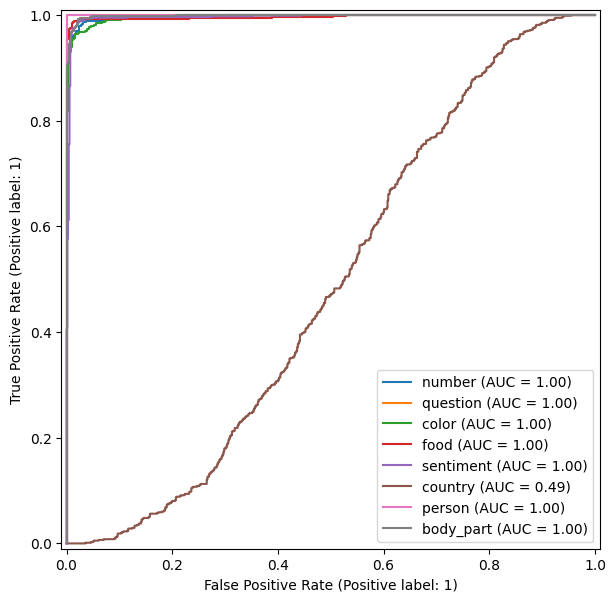

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

metric_rows = []
lp_accs = []
fig, ax = plt.subplots(figsize=(7,7))

for i in range(train_predictions.shape[1]):
    train_X = train_activations.numpy()
    train_y = train_labels[:,i]
    test_X = test_activations.numpy()
    test_y = test_labels[:,i]

    model = LogisticRegression(max_iter=1000, C=100).fit(train_X, train_y)

    pred = model.predict(test_X)
    scores = model.predict_proba(test_X)[:, 1]
    
    accuracy = accuracy_score(test_y, pred)
    f1 = f1_score(test_y, pred)
    auc = roc_auc_score(test_y, scores)

    lp_accs.append(accuracy)
    metric_rows.append({"feature": feature_names[i], "acc": accuracy, "f1": f1, "auc": auc})

    RocCurveDisplay.from_estimator(model, test_X, test_y, name=feature_names[i], ax=ax)
    # PrecisionRecallDisplay.from_estimator(model, test_X, test_y)

pd.DataFrame(metric_rows).style.background_gradient(cmap="RdYlGn", subset=["acc", "f1", "auc"])

# Reference diagonal (random classifier)
# ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
# ax.set_title("ROC per feature")
# ax.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


,feature,acc,f1,auc
0,number,0.975333,0.976947,0.997396
1,question,1.000000,1.000000,1.000000
2,color,0.972000,0.972763,0.997346
3,food,0.984000,0.983936,0.996122
4,sentiment,0.981333,0.982166,0.995970
5,country,0.966667,0.967320,0.993958
6,person,0.999333,0.999345,1.000000
7,body_part,0.980000,0.979730,0.998505


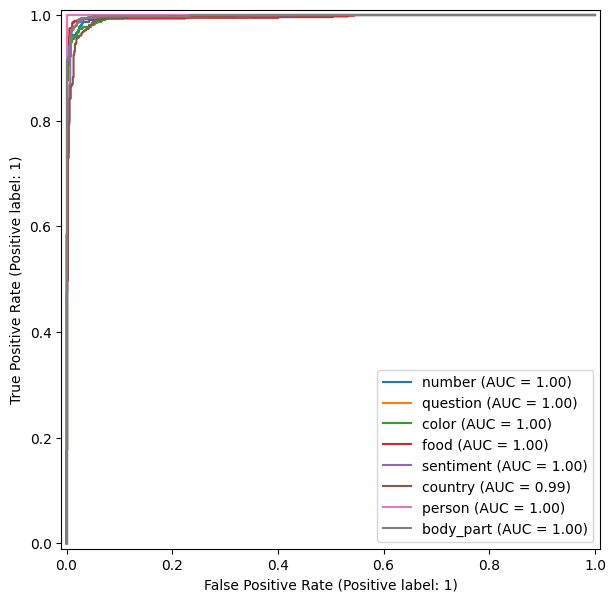

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

metric_rows = []
mlp_accs = []
fig, ax = plt.subplots(figsize=(7,7))

for i in range(train_predictions.shape[1]):
    train_X = train_activations.numpy()
    train_y = train_labels[:,i]
    test_X = test_activations.numpy()
    test_y = test_labels[:,i]

    model = MLPClassifier(hidden_layer_sizes=(64,64), max_iter=500).fit(train_X, train_y)

    pred = model.predict(test_X)
    scores = model.predict_proba(test_X)[:, 1]
    
    accuracy = accuracy_score(test_y, pred)
    f1 = f1_score(test_y, pred)
    auc = roc_auc_score(test_y, scores)

    mlp_accs.append(accuracy)
    metric_rows.append({"feature": feature_names[i], "acc": accuracy, "f1": f1, "auc": auc})

    RocCurveDisplay.from_estimator(model, test_X, test_y, name=feature_names[i], ax=ax)
    # PrecisionRecallDisplay.from_estimator(model, test_X, test_y)

pd.DataFrame(metric_rows).style.background_gradient(cmap="RdYlGn", subset=["acc", "f1", "auc"])

# Reference diagonal (random classifier)
# ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
# ax.set_title("ROC per feature")
# ax.legend(loc="lower right")
# plt.tight_layout()
# plt.show()


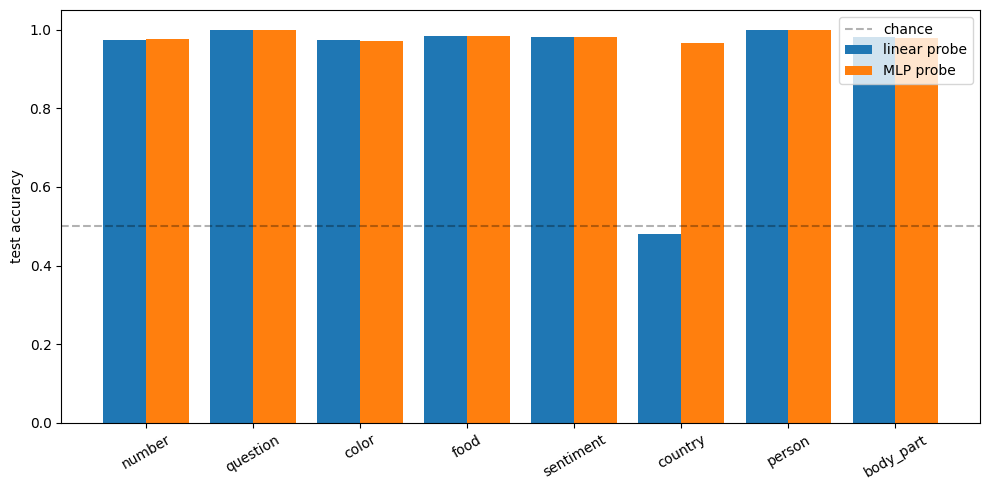

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# you'll need lp_accs and mlp_accs as length-8 arrays
x = np.arange(8)
w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, lp_accs,  w, label="linear probe")
ax.bar(x + w/2, mlp_accs, w, label="MLP probe")
ax.set_xticks(x); ax.set_xticklabels(feature_names, rotation=30)
ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="k", linestyle="--", alpha=0.3, label="chance")
ax.legend()
plt.tight_layout()

## Task 2: Explain how that feature is represented

Describe the geometric structure the model uses to represent this feature. Show the analysis you used to convince yourself.

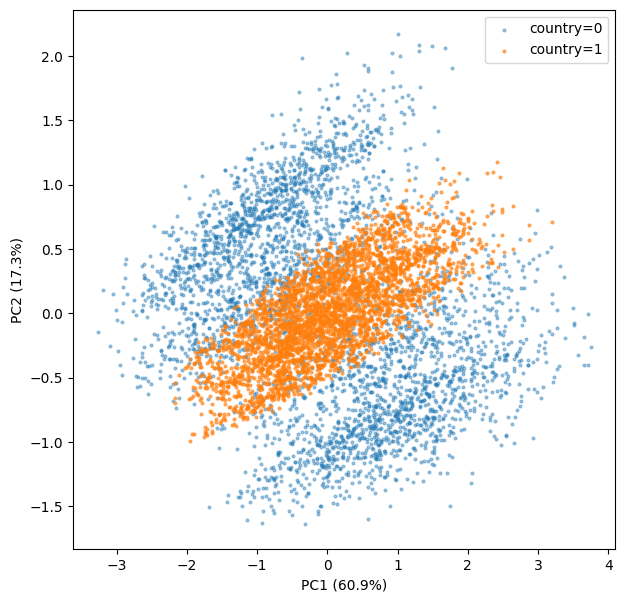

In [12]:
from sklearn.decomposition import PCA

X = train_activations.numpy()
y = train_labels[:, 5] # country

pca = PCA(n_components=2).fit(X)
X_reduced = pca.transform(X)

# X_reduced[:5]

fix, ax = plt.subplots(figsize=(7,7))
ax.scatter(X_reduced[y == 0, 0], X_reduced[y == 0, 1], s=4, alpha=0.4, label="country=0")
ax.scatter(X_reduced[y == 1, 0], X_reduced[y == 1, 1], s=4, alpha=0.6, label="country=1")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.legend()


In [13]:
X[y == 1]

array([[0.        , 1.0532206 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.92515445, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.81482506, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.6839998 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.6415777 , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.0622834 , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(3451, 64), dtype=float32)

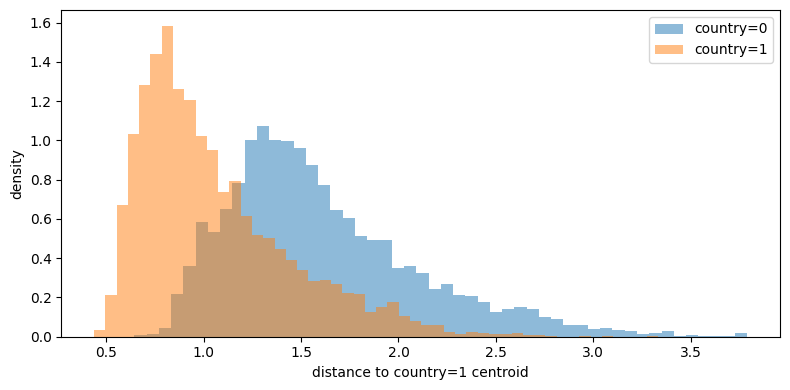

In [14]:
mu = X[y == 1].mean(axis=0)
dists = np.linalg.norm(X - mu, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dists[y == 0], bins=50, alpha=0.5, label="country=0", density=True)
ax.hist(dists[y == 1], bins=50, alpha=0.5, label="country=1", density=True)
ax.set_xlabel("distance to country=1 centroid")
ax.set_ylabel("density")
ax.legend()
plt.tight_layout()

## Task 3: Train a model with an even weirder representation

*Open ended.* Train your own model that encodes that feature (or some other feature) in a more interesting way than ours. "More interesting" is up to you to define and defend.

## What you'll submit

A single google doc, documenting what you tried, what worked, what didn't, and what structure emerged in the trained model. We'll happily read about your failures if the path to them was thoughtful.